# Assignment 2: Hand Gesture Recognition [50 Pt]

This assignment will be completed in two parts. In Part A you will gain experience gathering your own data set (specifically images of hand gestures), and understand the challenges involved in the data cleaning process. In Part B you will train a convolutional neural network to make classifications on different hand gestures. By the end of this assignment, you should be able to:

1. Generate and preprocess your own data
2. Load and split data for training, validation and testing
3. Train a Convolutional Neural Network
4. Apply transfer learning to improve your model

Note that for this assignment we will not be providing you with any starter code. You should be able to take the sample code provided in the preparation sample code, previous assignment, and lectures and modify it accordingly to complete the tasks outlined below.

*This assignment is based on an assignment developed by Prof. Lisa Zhang.*

### What to submit

**Submission for Part A:**  
Submit a zip file containing your images. Three images each of American Sign Language gestures for letters A - I (total of 27 images). You will be required to clean the images before submitting them. Details are provided under Part A of the handout.

Individual image file names should follow the convention of student-number_Alphabet_file-number.jpg
(e.g. 100343434_A_1.jpg).


**Submission for Part B:**  
Submit an HTML file containing all your code, outputs, and write-up
from parts A and B. You can produce a HTML file directly from Google Colab. The Colab instructions are provided at the end of this document.

**Do not submit any other files produced by your code.**

Include a link to your colab file in your submission.

Please use Google Colab to complete this assignment. If you want to use Jupyter Notebook, please complete the assignment and upload your Jupyter Notebook file to Google Colab for submission.

## Colab Link

Include a link to your colab file here and ensure the file can be accessed by the our teaching team.


In [ ]:
# TO BE COMPLETED

https://colab.research.google.com/drive/1EXUYmtEX1vEfOzXYtIPArtmNhodcLYkT?usp=sharing

# Part A. Data Collection [5pt]

So far, we have worked with data sets that have been collected, cleaned, and curated by machine learning
researchers and practitioners. Datasets like MNIST and CIFAR are often used as toy examples, both by
students and by researchers testing new machine learning models.

In the real world, getting a clean data set is never that easy. More than half the work in applying machine
learning is finding, gathering, cleaning, and formatting your data set.

The purpose of this assignment is to help you gain experience gathering your own data set, and understand the
challenges involved in the data cleaning process.

### American Sign Language

American Sign Language (ASL) is a complete, complex language that employs signs made by moving the
hands combined with facial expressions and postures of the body. It is the primary language of many
North Americans who are deaf and is one of several communication options used by people who are deaf or
hard-of-hearing.

The hand gestures representing English alphabet are shown below. This assignment focuses on classifying a subset
of these hand gesture images using convolutional neural networks. Specifically, given an image of a hand
showing one of the letters A-I, we want to detect which letter is being represented.

![alt text](https://www.disabled-world.com/pics/1/asl-alphabet.jpg)


### Generating Data
We will produce the images required to assess our models by ourselves. You are required to collect, clean and submit
three images each of Americal Sign Language gestures for letters A - I (total of 27 images)
Steps involved in data collection

1. Familiarize yourself with American Sign Language gestures for letters from A - I (9 letters).
2. Take three pictures at slightly different orientation for each letter gesture using your
mobile phone.
 - Ensure adequate lighting while you are capturing the images.
 - Use a white wall as your background.
 - Use your right hand to create gestures (for consistency).
 - Keep your right hand fairly apart from your body and any other obstructions.
 - Avoid having shadows on parts of your hand.
3. Transfer the images to your laptop for cleaning.

### Cleaning Data
To simplify the machine learning the task, we will standardize the training images. We will make sure that
all our images are of the same size (224 x 224 pixels RGB), and have the hand in the center of the cropped
regions.

You may use the following applications to crop and resize your images:

**Mac**
- Use Preview:
– Holding down CMD + Shift will keep a square aspect ratio while selecting the hand area.
– Resize to 224x224 pixels.

**Windows 10**
- Use Photos app to edit and crop the image and keep the aspect ratio a square.
- Use Paint to resize the image to the final image size of 224x224 pixels.

**Linux**
- You can use GIMP, imagemagick, or other tools of your choosing.
You may also use online tools such as http://picresize.com
All the above steps are illustrative only. You need not follow these steps but following these will ensure that
you produce a good quality dataset. You will be judged based on the quality of the images alone.
Please do not edit your photos in any other way. You should not need to change the aspect ratio of your
image. You also should not digitally remove the background or shadows—instead, take photos with a white
background and minimal shadows.

### Accepted Images
Images will be accepted and graded based on the criteria below
1. The final image should be size 224x224 pixels (RGB).
2. The file format should be a .jpg file.
3. The hand should be approximately centered on the frame.
4. The hand should not be obscured or cut off.
5. The photos follows the ASL gestures posted earlier.
6. The photos were not edited in any other way (e.g. no electronic removal of shadows or background).

### Submission
Submit a zip file containing your images. There should be a total of 27 images (3 for each category)
1. Individual image file names should follow the convention of student-number_Alphabet_file-number.jpg
(e.g. 100343434_A_1.jpg)
2. Zip all the images together and name it with the following convention: last-name_student-number.zip
(e.g. last-name_100343434.zip).
3. Submit the zipped folder.

![alt text](https://github.com/UTNeural/APS360/blob/master/Gesture%20Images.PNG?raw=true)

# Part B. Building a CNN [45pt]

For this assignment, we are not going to give you any starter code. You will be writing a convolutional neural network
from scratch. You are welcome to modify and combine code provided previously in the course (assignments, preparation code, lectures, etc.). You can also write your own code.

You may use the PyTorch documentation freely. You might also find online tutorials helpful. However, all code that you submit must be be your own. You cannot take a completed assignment and claim it as your own.

Make sure that your code is vectorized, and does not contain obvious inefficiencies (for example, unecessary
for loops, or unnecessary calls to unsqueeze()). Ensure enough comments are included in the code so that
your TA can understand what you are doing. It is your responsibility to show that you understand what you
write.

**This is much more challenging and time-consuming than the previous assignments.** Make sure that you give yourself plenty of time by starting early.

## Part 1. Data Loading and Splitting [3pt EXPLORATORY]

Download the anonymized data provided on Quercus. Split the data into training, validation, and test sets.

Note: Data splitting is not as trivial in this assignment. We want our test set to closely resemble the setting in which
our model will be used. In particular, our test set should contain hands that are never seen in training!

Explain how you split the data, either by describing what you did, or by showing the code that you used.
Justify your choice of splitting strategy. How many training, validation, and test images do you have?

For loading the data, you can use plt.imread, or any other method that you choose. You may find
torchvision.datasets.ImageFolder helpful. (see https://pytorch.org/vision/main/generated/torchvision.datasets.ImageFolder.html)
)

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
import os
import time
from dataclasses import dataclass
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.nn.modules.loss import _Loss
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import ImageFolder
from torchvision import datasets, transforms

In [ ]:
import zipfile

with zipfile.ZipFile('A2_Hand_Gesture_Dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('my_dataset')


In [ ]:
pip install split-folders

In [ ]:
import splitfolders
splitfolders.ratio('/content/my_dataset/Lab_3b_Gesture_Dataset', output='output', seed=1337, ratio=(0.8, 0.1,0.1))

Copying files: 2431 files [00:00, 3230.33 files/s]


In [ ]:
use_cuda = True and torch.cuda.is_available()
device = torch.device('cuda' if use_cuda else 'cpu')

In [ ]:
def get_data_loaders(batch_size: int, **kwargs):

    # Transforming the images to Tensors, resizing and normalizing
    mean = [0.485, 0.456, 0.406] #Commonly used values for RGB channels
    std = [0.229, 0.224, 0.225] #Commonly used values for RGB channels

    data_transform = transforms.Compose([transforms.RandomResizedCrop(224), transforms.ToTensor(),
                                         transforms.Normalize(mean, std)])

    # Loading the dataset
    data_dir = '/content/output'

    train_dir = os.path.join(data_dir, 'train')
    val_dir = os.path.join(data_dir, 'val')
    test_dir = os.path.join(data_dir, 'test')

    train_data = ImageFolder(train_dir, transform=data_transform)
    val_data = ImageFolder(val_dir, transform=data_transform)
    test_data = ImageFolder(test_dir, transform=data_transform)

    # prepare data loaders
    train_load = DataLoader(train_data, batch_size=batch_size,
                                           num_workers=1, shuffle=True)
    val_load = DataLoader(val_data, batch_size=batch_size,
                                          num_workers=1, shuffle=True)
    test_load = DataLoader(test_data, batch_size=batch_size,
                                          num_workers=1, shuffle=True)

    return train_load, val_load, test_load


In [ ]:
train_loader, val_loader, test_loader = get_data_loaders(batch_size= 64)

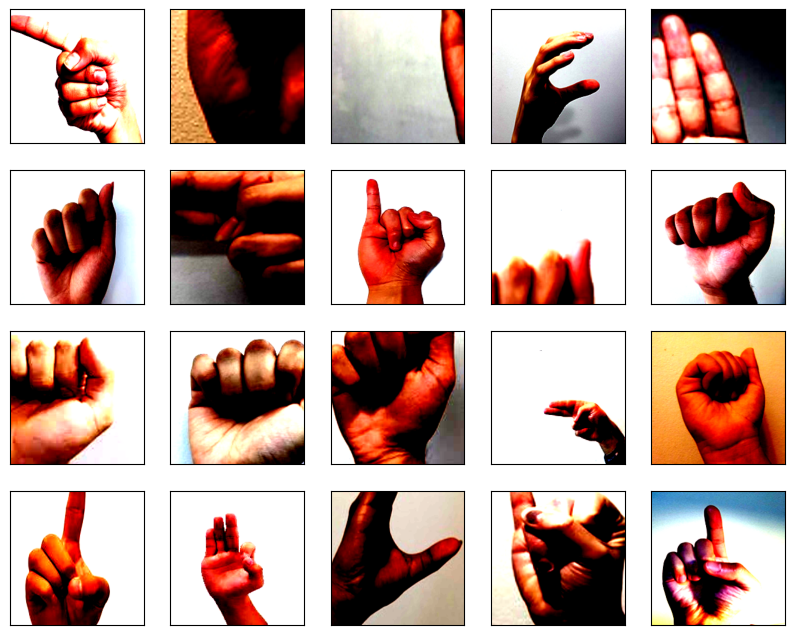

In [ ]:
k = 0
fig = plt.figure(figsize=(10, 8))

for images, labels in train_loader:
    for image in images:
        image = image.numpy()  # Convert the image to numpy for display
        image = np.clip(image, 0, 1)  # Clip values to the [0, 1] range (for float data)

        ax = fig.add_subplot(4, 5, k + 1, xticks=[], yticks=[])
        plt.imshow(np.transpose(image, [1, 2, 0]))
        k += 1

        if k >= 20:
            break

    if k >= 20:
        break

plt.show()


In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

For splitting the data that closely resembles the setting in which our model will be used and also to make sure that our test set
contains hands that are never seen in training, I have made use of a library called split-folders which automatically takes a source directory
containing our dataset and splits it into user-defined ratios, such as training, validation, and test sets. The data is distributed properly
into the specified folders without duplication.

Another way of doing the above job would be to follow stratified sampling rather than random sampling. In stratified sampling,
the dataset is divided into mutually exclusive subgroups or strata based on a particular attribute or characteristic.
Within each stratum, samples are randomly selected in proportion to the stratum's representation in the overall population.
This ensures that each stratum is adequately represented in the sample.

'''

In [ ]:
traindataset_path = Path('/content/output/train')
valdataset_path = Path('/content/output/val')
testdataset_path = Path('/content/output/test')

print('Number of images in train folder:')
for folder in traindataset_path.iterdir():
    print(f'{folder.name}: {len(list(folder.iterdir()))}')

print('Number of images in validation folder:')
for folder in valdataset_path.iterdir():
    print(f'{folder.name}: {len(list(folder.iterdir()))}')

print('Number of images in test folder:')
for folder in testdataset_path.iterdir():
    print(f'{folder.name}: {len(list(folder.iterdir()))}')

Number of images in train folder:
F: 218
C: 218
I: 199
E: 217
G: 218
H: 218
B: 218
A: 217
D: 218
Number of images in validation folder:
F: 27
C: 27
I: 24
E: 27
G: 27
H: 27
B: 27
A: 27
D: 27
Number of images in test folder:
F: 28
C: 28
I: 26
E: 28
G: 28
H: 28
B: 28
A: 28
D: 28


### In total, we have 1941 training samples, 240 validation samples and 250 test samples and the split of number of samples for each letter in train, test and validation is shown above.

## Part 2. Model Building and Sanity Checking [5pt]

### Part (i) Convolutional Network [2pt MODEL]

Build a convolutional neural network model that takes the (224x224 RGB) image as input, and predicts the gesture
letter. Your model should be a subclass of nn.Module. Explain your choice of neural network architecture: how
many layers did you choose? What types of layers did you use? Were they fully-connected or convolutional?
What about other decisions like pooling layers, activation functions, number of channels / hidden units?

In [ ]:
img_size= 224
output_channels= 9

class ASL(nn.Module):

  def __init__(self, kernel_size: int = 3):
    super(ASL, self).__init__()
    self.name = f'{self.__class__.__name__}_{kernel_size}'

    conv_fcl = 30
    maxpool_1 = 2
    maxpool_2 = 5

    self.conv1 = nn.Conv2d(3, 10, kernel_size)
    self.pool1 = nn.MaxPool2d(maxpool_1, maxpool_1) #Assuming the kernel size and stride is the same
    self.conv2 = nn.Conv2d(10, 20, kernel_size + 2)
    self.pool2 = nn.MaxPool2d(maxpool_2, maxpool_2) #Assuming the kernel size and stride is the same
    self.conv3 = nn.Conv2d(20, conv_fcl, kernel_size)

    dim1 = math.floor((1 / maxpool_1) * (img_size - kernel_size + 1))  #Dimension after first conv and maxpool1
    dim2 = math.floor((1 / maxpool_2) * (dim1 - (kernel_size + 2) + 1)) #Dimension after second conv and maxpool2
    dim3 = math.floor((1 / maxpool_1) * (dim2 - kernel_size + 1)) #Dimension after third conv and maxpool1

    self.fcl_input = (dim3 * dim3) * conv_fcl
    self.fcl1 = nn.Linear(self.fcl_input, 1024)
    self.fcl2 = nn.Linear(1024, output_channels) #Number of outputs is 9 (A-I)

  def forward(self, x):
    x = self.pool1(F.relu(self.conv1(x)))
    x = self.pool2(F.relu(self.conv2(x)))
    x = self.pool1(F.relu(self.conv3(x)))

    x = x.view(-1, self.fcl_input)  #flatten before FCL
    x = F.relu(self.fcl1(x))
    x = self.fcl2(x)

    return x


In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

The neural network architecture chosen here consists of 3 convolution layers and 2 fully connected layers.
The first layer contains 3 input channels for RGB inputs and has 10 output channels. The kernel size is kept as a variable which can be altered thus acting as a hyperparameter.
Following this, we have maxpool1 which has a kernel size and stride of 2, thereby halving the dimensions of input images.

The second layer contains 10 input channels and has 20 output channels and the kernel size is bigger by 2 units than the previous layer.
Following this, we have maxpool2 which has a kernel size and stride of 5, thereby reducing the dimensions of input images by 5 times.

The third layer contains 20 input channels and has 30 output channels.
Following this, the network is connected to fully connected layers.
The number of channels for the first fully connected layer is calculated based on the other layers, while I have selected the second fully connected layer to have 1024 units.
The final layer contains 9 units as outputs, one for each class from A to I.

Finally, the network also consists of ReLU function as the activation function after each of the convolution layers which prevents the vanishing gradients.

'''

### Part (ii) Training Code [2pt MODEL]

Write code that trains your neural network given some training data. Your training code should make it easy
to tweak the usual hyperparameters, like batch size, learning rate, and the model object itself. Make sure
that you are checkpointing your models from time to time (the frequency is up to you). Explain your choice
of loss function and optimizer.

In [ ]:
def get_accuracy(model: ASL, criterion: _Loss, loader: DataLoader):
    total_loss = 0
    iters = 0

    correct = 0
    total = 0

    for imgs, labels in loader:

      imgs = imgs.to(device)
      labels = labels.to(device)

      out = model(imgs)

      # selecting index with maximum prediction score
      pred = out.max(1, keepdim=True)[1]

      total += imgs.shape[0]
      correct += pred.eq(labels.view_as(pred)).sum().item()

      loss = criterion(out, labels)
      total_loss += loss.item()
      iters+= 1

    final_loss = float(total_loss) / (iters)
    acc = float(correct / total)

    return final_loss, acc

def generate_model_path(name, batch_size, learning_rate, num_epochs):

    return Path(f'model_{name}_bs{batch_size}_lr{learning_rate}_epoch{num_epochs}')

class TrainingResult:
    def __init__(self,
        training_accuracy: float,
        training_loss: float,
        validation_accuracy: float,
        validation_loss: float):

        self.training_accuracy = training_accuracy
        self.training_loss = training_loss
        self.validation_accuracy = validation_accuracy
        self.validation_loss = validation_loss

    def __repr__(self):
        return (
            f'\nTrainingResult(Training_accuracy={self.training_accuracy},'
            f'\ntraining_loss={self.training_loss},'
            f'\nValidation_accuracy={self.validation_accuracy},'
            f'\nValidation_loss={self.validation_loss})')


In [ ]:
def train(model: ASL, train_loader: DataLoader, val_loader: DataLoader, batch_size= 64, learning_rate= 0.01, num_epochs=30):

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr= learning_rate, momentum=0.9)

    train_acc, val_acc, train_loss, val_loss = [], [], [], []

    for epoch in range(num_epochs):

        total_train_loss = 0
        total = 0
        correct = 0
        iters = 0

        for imgs, labels in train_loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            output = model(imgs) #Forward pass
            loss = criterion(output, labels) #Compute the total loss
            loss.backward() #Backward pass
            optimizer.step() #Parameter Updates
            optimizer.zero_grad() #Clean up step

            # save the current training information
            total_train_loss += loss.item()
            iters+=1

        # Saving Loss and accuracy for training
        pred = output.max(1, keepdim=True)[1]
        correct += pred.eq(labels.view_as(pred)).sum().item()
        total += imgs.shape[0]
        train_loss.append(float(total_train_loss/iters))
        train_acc.append(float(correct/total))

        # Saving Loss and accuracy for validation
        with torch.no_grad(): #No gradient calc is required for val
          val_ls, val_ac = get_accuracy(model, criterion, loader= val_loader)

        val_loss.append(val_ls)
        val_acc.append(val_ac)

        #Saving the model(checkpoint) to a file in google drive
        model_path = generate_model_path(model.name, train_loader.batch_size, learning_rate, epoch + 1)
        torch.save(model.state_dict(), model_path)

    plt.figure(figsize=(10,4))
    plt.title('Training Vs. Validation Accuracy')
    n_epochs = len(train_acc)
    plt.plot(range(1, n_epochs + 1), train_acc, label='Train')
    plt.plot(range(1, n_epochs + 1), val_acc, label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend(loc='best')
    plt.show()

    plt.figure(figsize=(10,4))
    plt.title('Training Vs. Validation Loss')
    plt.plot(range(1, n_epochs + 1), train_loss, label='Train')
    plt.plot(range(1, n_epochs + 1), val_loss, label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend(loc='best')
    plt.show()

    print('Finished Training\n',
        'Final Training Accuracy: {} %\n'.format(train_acc[-1] * 100),
        'Final Validation Accuracy: {} %\n'.format(val_acc[-1] * 100)
         )

    return TrainingResult(train_acc[-1], train_loss[-1], val_acc[-1], val_loss[-1])


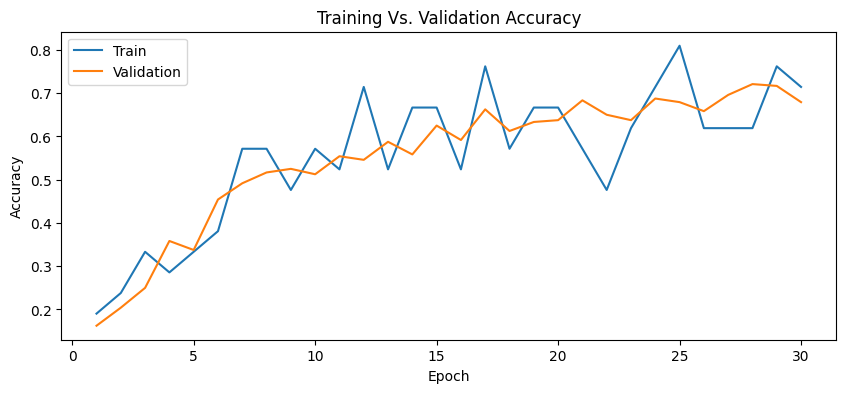

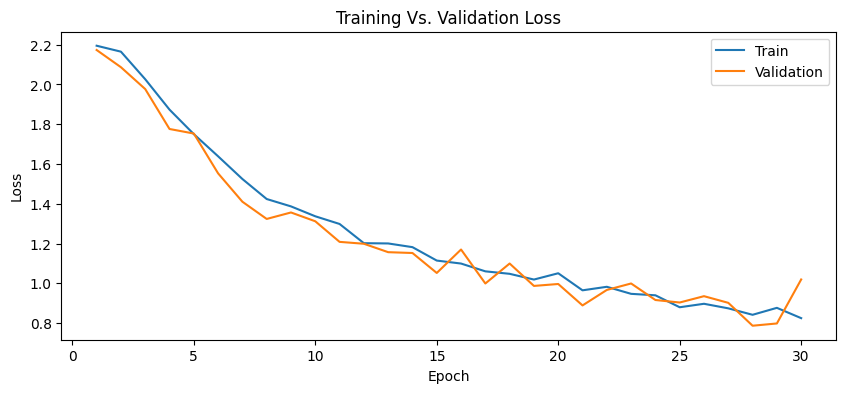

Finished Training
 Final Training Accuracy: 71.42857142857143 %
 Final Validation Accuracy: 67.91666666666667 %




TrainingResult(Training_accuracy=0.7142857142857143,
training_loss=0.8245797041923769,
Validation_accuracy=0.6791666666666667,
Validation_loss=1.0191495418548584)

In [ ]:
demo_model = ASL().to(device)
use_cuda = True

hyper_params = dict(batch_size=64, learning_rate=0.01, num_epochs= 30)

train_loader, val_loader, test_loader = get_data_loaders(** hyper_params)

train(demo_model, train_loader, val_loader, ** hyper_params)

In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

The CrossEntropyLoss was selected as the loss function as we needed to classify multiple classes and this is designed for classification tasks.
Also, it is compatible with gradient-based optimization algorithms like SGD.
For optimizer, Stochastic Gradient Descent optimizer was chosen as it requires less memory and computation compared to Adam.
This is beneficial when working with limited computational resources which is the case for us.

'''

### Part (iii) “Overfit” to a Small Dataset - [1pt MODEL]

One way to sanity check our neural network model and training code is to check whether the model is capable
of “overfitting” or “memorizing” a small dataset. A properly constructed CNN with correct training code
should be able to memorize the answers to a small number of images quickly.

Construct a small dataset (e.g. just the images that you have collected). Then show that your model and
training code is capable of memorizing the labels of this small data set.

With a large batch size (e.g. the entire small dataset) and learning rate that is not too high, you should be
able to obtain a 100% training accuracy on that small dataset relatively quickly (within 200 iterations).

In [ ]:
with zipfile.ZipFile('tennetiprabakaramurthy_1008628601.zip', 'r') as zip_ref:
    zip_ref.extractall('personal_dataset')

In [ ]:
# Transforming the images to Tensors and resizing
data_transform = transforms.Compose([transforms.RandomResizedCrop(224),
                                        transforms.ToTensor()])

data_dir = '/content/personal_dataset'

sanity_data = ImageFolder(data_dir, transform=data_transform)

train_size = int(0.8 * len(sanity_data))
val_size = len(sanity_data) - train_size
train_set, val_set = torch.utils.data.random_split(sanity_data, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_loader_sanity = DataLoader(train_set, batch_size=30)
val_loader_sanity = DataLoader(val_set, batch_size=30)


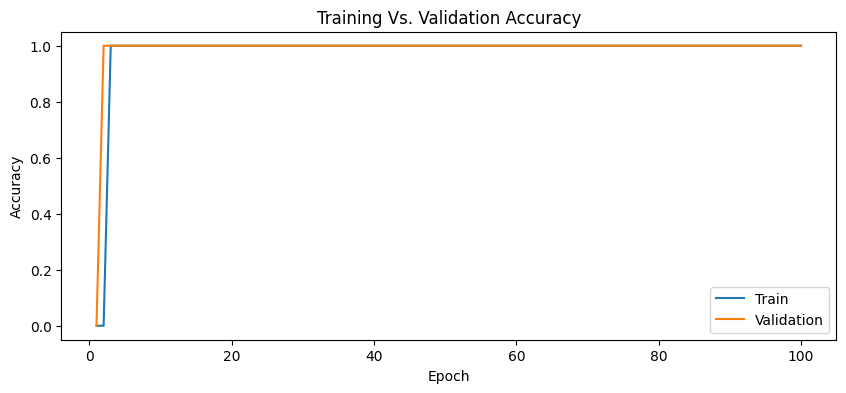

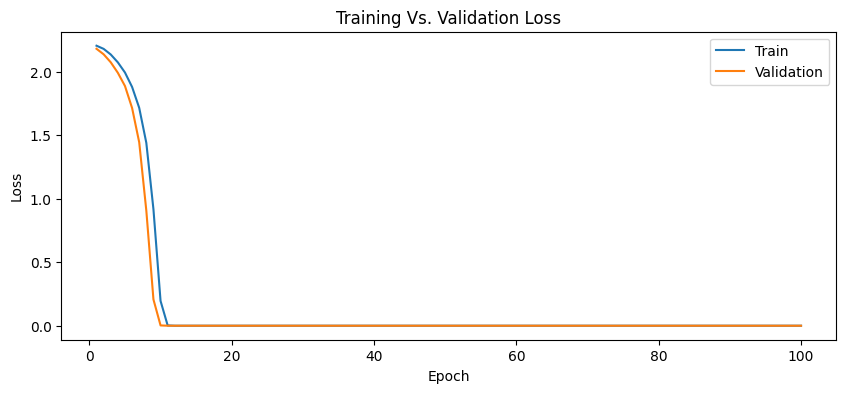

Finished Training
 Final Training Accuracy: 100.0 %
 Final Validation Accuracy: 100.0 %




TrainingResult(Training_accuracy=1.0,
training_loss=0.0,
Validation_accuracy=1.0,
Validation_loss=0.0)

In [ ]:
sanity_model = ASL().to(device)

# Hyperparameters
sanity_hyper_params = dict(batch_size=30, num_epochs=100, learning_rate=0.01)

train(sanity_model, train_loader_sanity, val_loader_sanity, **sanity_hyper_params)

## Part 3. Hyperparameter Search [7pt]

### Part (i) - [2pt EXPLORATORY]

List 3 hyperparameters that you think are most worth tuning. Choose at least one hyperparameter related to
the model architecture.

In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

The three hyperparameters that I think are worth tuning are the learning rate, batch size and the kernel size.
The kernel size hyperparameter is related to the model architecture.

I chose these three hyperparameters due to following reasons:

Learning rate significantly impacts training convergence and model performance. Choosing an appropriate learning rate ensures efficient training and accurate ASL gesture recognition.
Batch size affects the speed of training and the model's ability to generalize. Optimizing batch size balances computational efficiency and model accuracy.
Kernel size in convolutional layers influences the model's ability to capture spatial features. Tuning kernel size optimizes feature extraction and recognition capabilities.

'''

### Part (ii) - [1pt MODEL]

Tune the hyperparameters you listed in Part (i), trying as many values as you need to until you feel satisfied
that you are getting a good model. Plot the training curve of at least 4 different hyperparameter settings.

# **Sample 1: Kernel Size: 5**

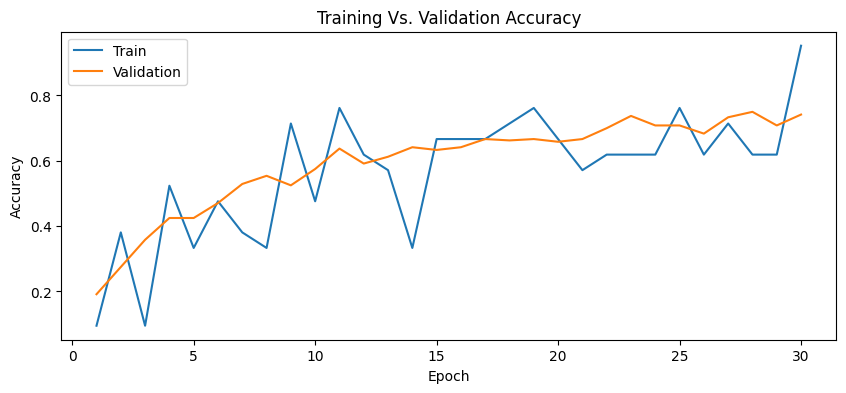

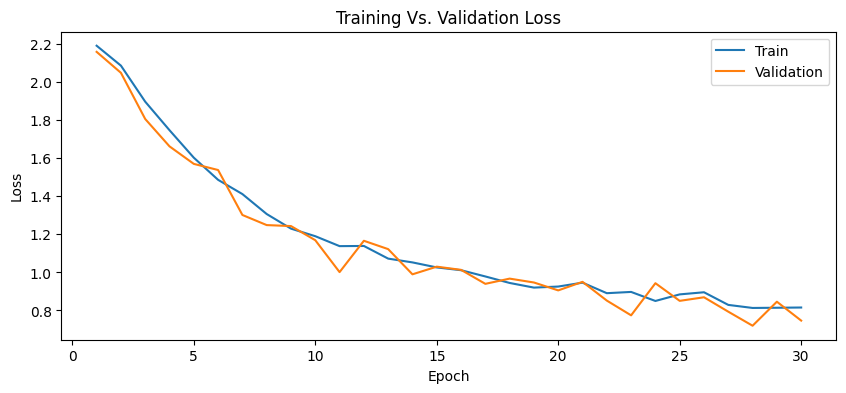

Finished Training
 Final Training Accuracy: 95.23809523809523 %
 Final Validation Accuracy: 74.16666666666667 %




TrainingResult(Training_accuracy=0.9523809523809523,
training_loss=0.8153762903905684,
Validation_accuracy=0.7416666666666667,
Validation_loss=0.7465710341930389)

In [ ]:
sample_model1 = ASL(kernel_size=5).to(device)

# Hyperparameters
hyper_params_sample1 = dict(batch_size=64, num_epochs=30, learning_rate=0.01)

train_loader_sample1, val_loader_sample1, test_loader_sample1 = get_data_loaders(** hyper_params_sample1)

train(sample_model1, train_loader_sample1, val_loader_sample1, ** hyper_params_sample1)


# **Sample 2: Learning rate: 0.1**

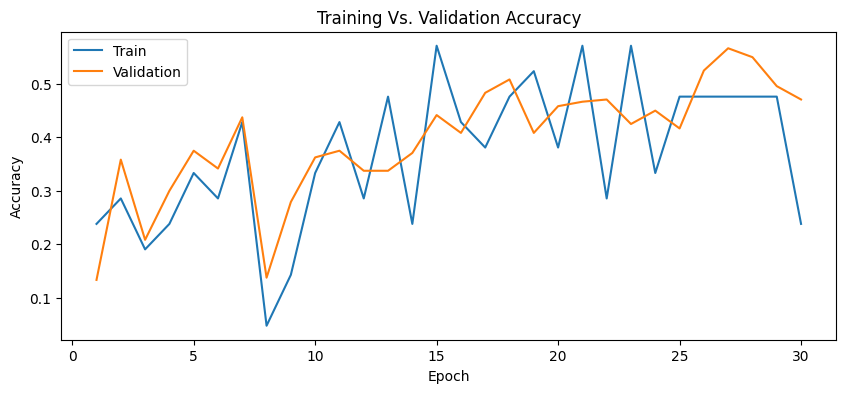

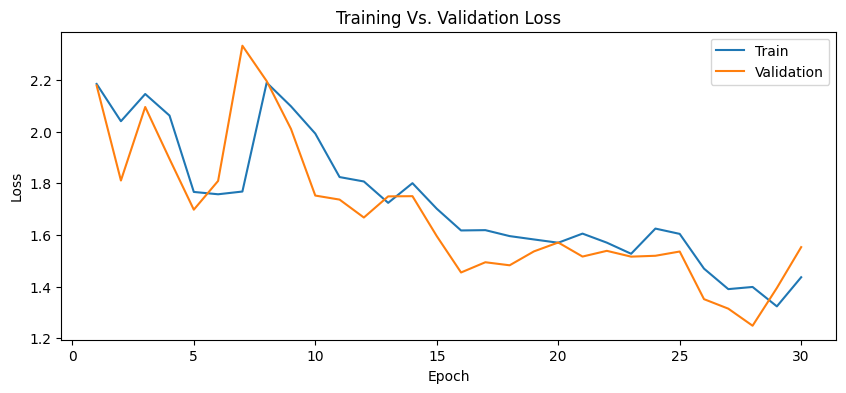

Finished Training
 Final Training Accuracy: 23.809523809523807 %
 Final Validation Accuracy: 47.083333333333336 %




TrainingResult(Training_accuracy=0.23809523809523808,
training_loss=1.4361899168260637,
Validation_accuracy=0.4708333333333333,
Validation_loss=1.5526766180992126)

In [ ]:
sample_model2 = ASL().to(device)

# Hyperparameters
hyper_params_sample2 = dict(batch_size=64, num_epochs=30, learning_rate=0.1)

train_loader_sample2, val_loader_sample2, test_loader_sample2 = get_data_loaders(** hyper_params_sample2)

train(sample_model2, train_loader_sample2, val_loader_sample2, ** hyper_params_sample2)

# **Sample 3: Batch Size: 32**

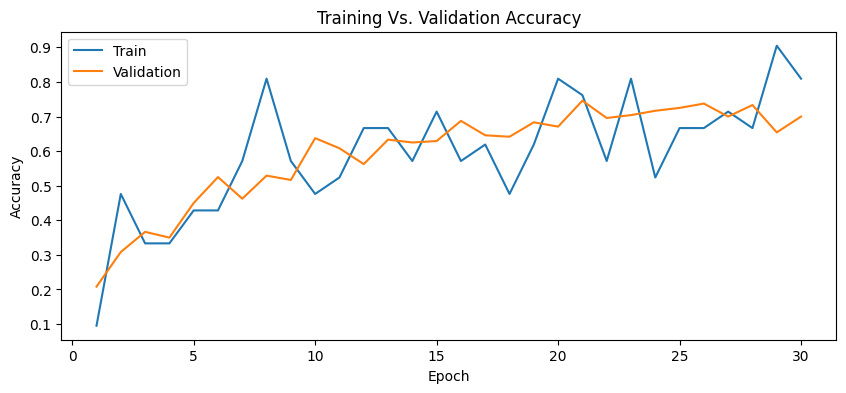

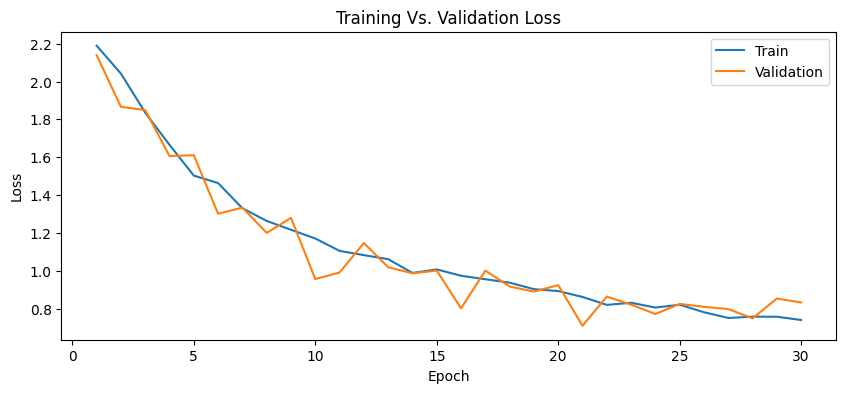

Finished Training
 Final Training Accuracy: 80.95238095238095 %
 Final Validation Accuracy: 70.0 %




TrainingResult(Training_accuracy=0.8095238095238095,
training_loss=0.7407020833648619,
Validation_accuracy=0.7,
Validation_loss=0.8329895809292793)

In [ ]:
sample_model3 = ASL().to(device)

# Hyperparameters
hyper_params_sample3 = dict(batch_size=32, num_epochs=30, learning_rate=0.01)

train_loader_sample3, val_loader_sample3, test_loader_sample3 = get_data_loaders(** hyper_params_sample3)

train(sample_model3, train_loader_sample3, val_loader_sample3, ** hyper_params_sample3)

# **Sample 4: Kernel Size: 7**

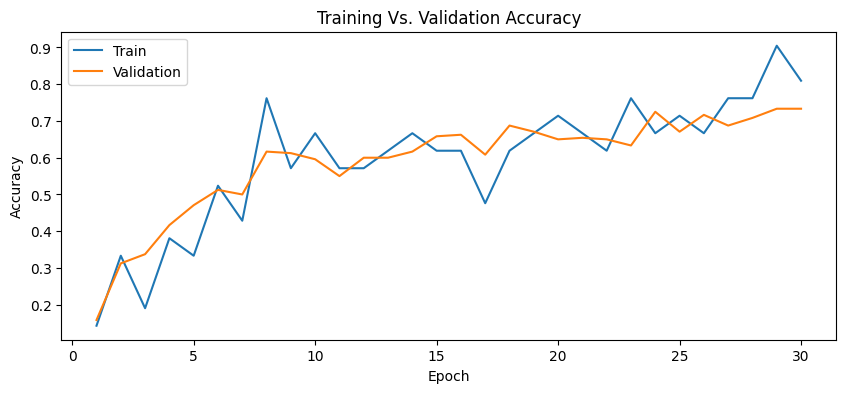

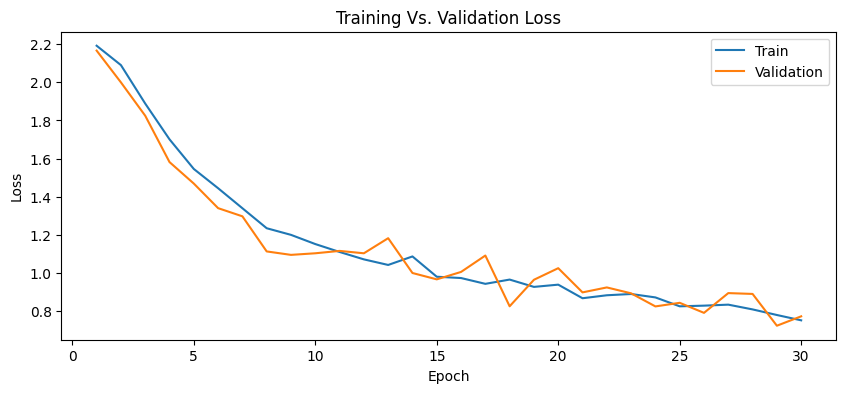

Finished Training
 Final Training Accuracy: 80.95238095238095 %
 Final Validation Accuracy: 73.33333333333333 %




TrainingResult(Training_accuracy=0.8095238095238095,
training_loss=0.752912457912199,
Validation_accuracy=0.7333333333333333,
Validation_loss=0.7738597542047501)

In [ ]:
sample_model4 = ASL(kernel_size=7).to(device)

# Hyperparameters
hyper_params_sample4 = dict(batch_size=64, num_epochs=30, learning_rate=0.01)

train_loader_sample4, val_loader_sample4, test_loader_sample4 = get_data_loaders(** hyper_params_sample4)

train(sample_model4, train_loader_sample4, val_loader_sample4, ** hyper_params_sample4)

# **Sample 5: Learning rate: 0.001**

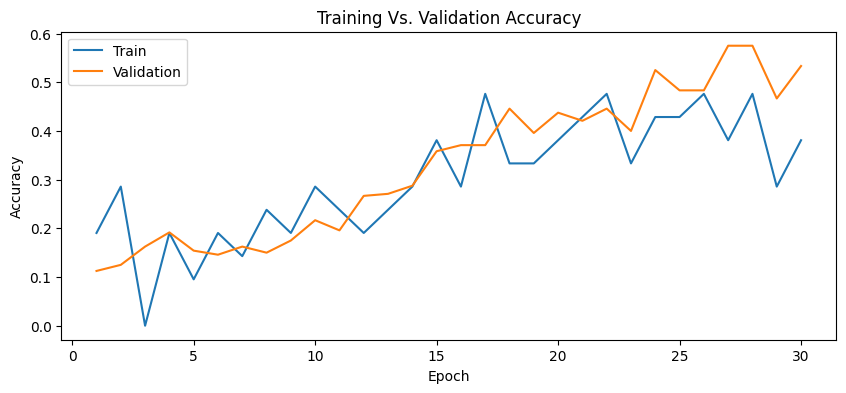

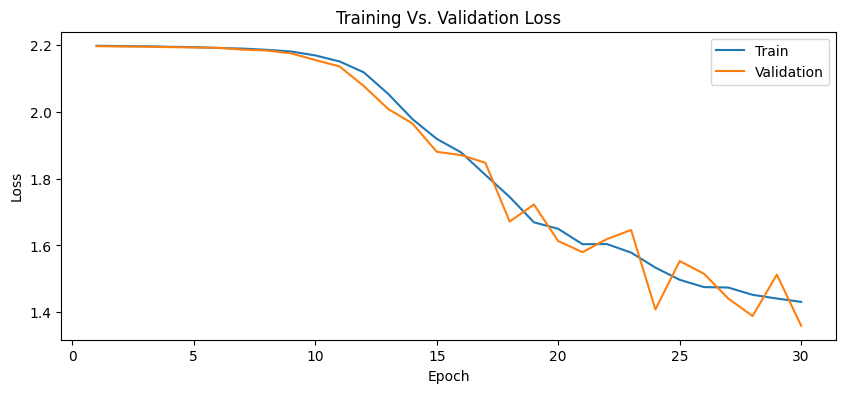

Finished Training
 Final Training Accuracy: 38.095238095238095 %
 Final Validation Accuracy: 53.333333333333336 %




TrainingResult(Training_accuracy=0.38095238095238093,
training_loss=1.4310243706549368,
Validation_accuracy=0.5333333333333333,
Validation_loss=1.3596909046173096)

In [ ]:
sample_model5 = ASL().to(device)

# Hyperparameters
hyper_params_sample5 = dict(batch_size=64, num_epochs=30, learning_rate=0.001)

train_loader_sample5, val_loader_sample5, test_loader_sample5 = get_data_loaders(** hyper_params_sample5)

train(sample_model5, train_loader_sample5, val_loader_sample5, ** hyper_params_sample5)

# **Sample 6: Batch Size: 128**

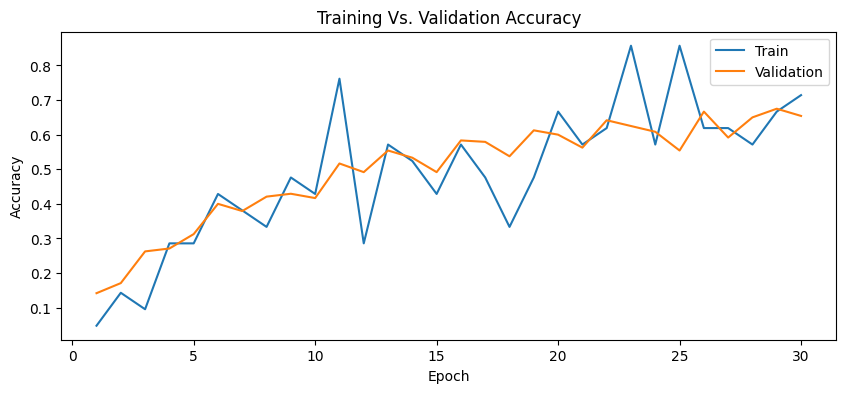

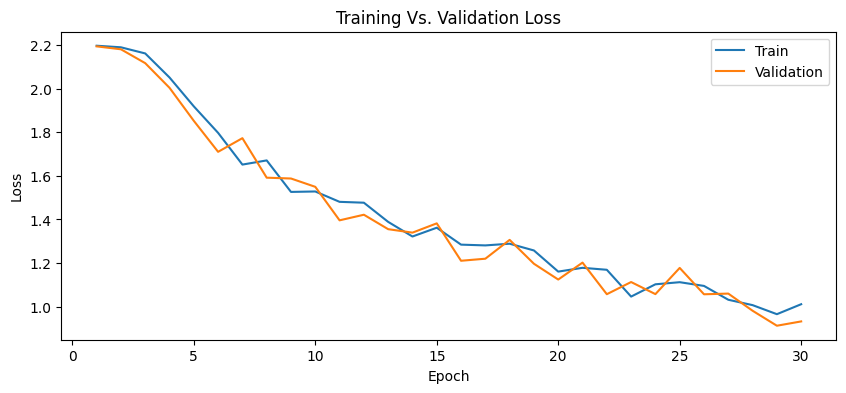

Finished Training
 Final Training Accuracy: 71.42857142857143 %
 Final Validation Accuracy: 65.41666666666667 %




TrainingResult(Training_accuracy=0.7142857142857143,
training_loss=1.0117818377912045,
Validation_accuracy=0.6541666666666667,
Validation_loss=0.9329644441604614)

In [ ]:
sample_model6 = ASL().to(device)

# Hyperparameters
hyper_params_sample6 = dict(batch_size=128, num_epochs=30, learning_rate=0.01)

train_loader_sample6, val_loader_sample6, test_loader_sample6 = get_data_loaders(** hyper_params_sample6)

train(sample_model6, train_loader_sample6, val_loader_sample6, ** hyper_params_sample6)

# **Sample 7: Batch Size: 32, Kernel Size: 5, Learning Rate: 0.01**

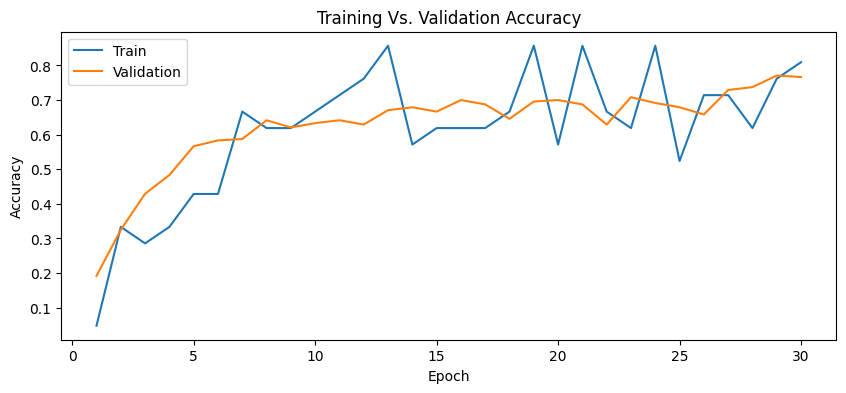

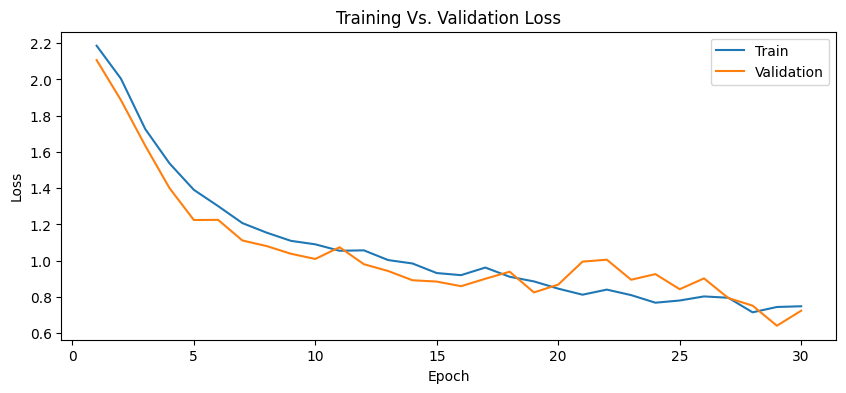

Finished Training
 Final Training Accuracy: 80.95238095238095 %
 Final Validation Accuracy: 76.66666666666667 %




TrainingResult(Training_accuracy=0.8095238095238095,
training_loss=0.7487075905330846,
Validation_accuracy=0.7666666666666667,
Validation_loss=0.7241397723555565)

In [ ]:
sample_model7 = ASL(kernel_size=5).to(device)

# Hyperparameters
hyper_params_sample7 = dict(batch_size=32, num_epochs=30, learning_rate=0.01)

train_loader_sample7, val_loader_sample7, test_loader_sample7 = get_data_loaders(** hyper_params_sample7)

train(sample_model7, train_loader_sample7, val_loader_sample7, ** hyper_params_sample7)

# **Sample 8: Batch Size: 128, Kernel Size: 5, Learning Rate: 0.05**

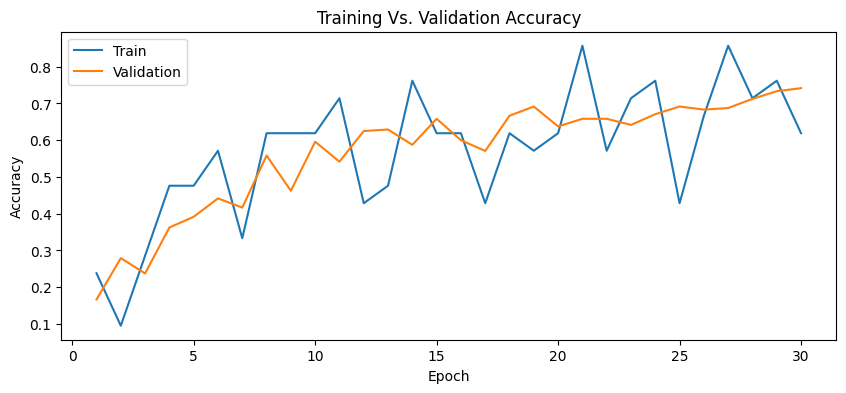

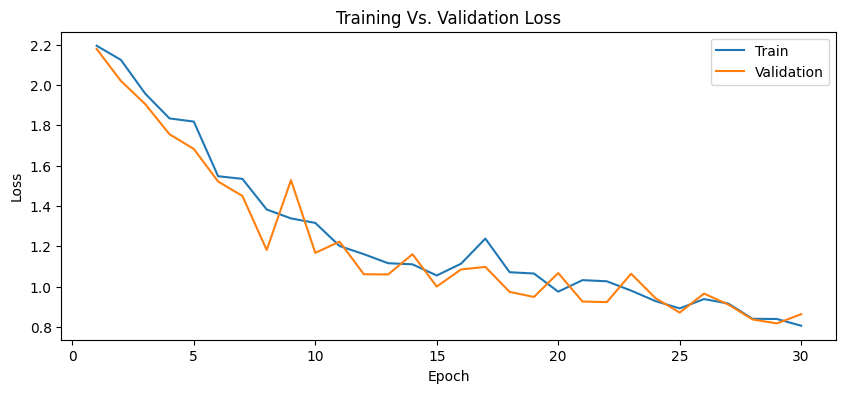

Finished Training
 Final Training Accuracy: 61.904761904761905 %
 Final Validation Accuracy: 74.16666666666667 %




TrainingResult(Training_accuracy=0.6190476190476191,
training_loss=0.8056749366223812,
Validation_accuracy=0.7416666666666667,
Validation_loss=0.8628749251365662)

In [ ]:
sample_model8 = ASL(kernel_size=5).to(device)

# Hyperparameters
hyper_params_sample8 = dict(batch_size=128, num_epochs=30, learning_rate=0.05)

train_loader_sample8, val_loader_sample8, test_loader_sample8 = get_data_loaders(** hyper_params_sample8)

train(sample_model8, train_loader_sample8, val_loader_sample8, ** hyper_params_sample8)

### Part (iii) - [2pt DISCUSSION]
Choose the best model out of all the ones that you have trained. Justify your choice.

In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

The best model chosen is the one containing these hyperparameters:
Kernel Size- Kernel size of 5 produced the best training as well as validation accuracy.
Learning rate- The default learning rate of 0.01 proved to be the best in producing higher accurate results.
Batch size- The batch size of 32 produced the best validation accuracy as well.

Moreover, the model which used the combination of all these 3 hyperparameters produced the best validation accuracy across all the models tried.
Thus, this is chosen as the best model.

'''

### Part (iv) - [2pt RESULTS]
Report the test accuracy of your best model. You should only do this step once and prior to this step you should have only used the training and validation data.

In [ ]:
best_model = ASL(kernel_size=5).to(device)
best_hyper_params = dict(batch_size=32, num_epochs=30, learning_rate=0.01)

model_path = generate_model_path(best_model.name, **best_hyper_params)
state = torch.load(model_path)
best_model.load_state_dict(state)

<All keys matched successfully>

In [ ]:
criterion = nn.CrossEntropyLoss()

_, _, test_loader = get_data_loaders(** best_hyper_params)

test_loss, test_acc = get_accuracy(best_model, criterion, test_loader)
print(f"Test Accuracy: {test_acc * 100} %\nTest Loss: {test_loss}")

Test Accuracy: 76.8 %
Test Loss: 0.6580936834216118


In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

The test accuracy for the model was 76.8%
The test loss for the model was 0.659

'''

## Part 4. Transfer Learning [8pt]
For many image classification tasks, it is generally not a good idea to train a very large deep neural network
model from scratch due to the enormous compute requirements and lack of sufficient amounts of training
data.

One of the better options is to try using an existing model that performs a similar task to the one you need
to solve. This method of utilizing a pre-trained network for other similar tasks is broadly termed **Transfer
Learning**. In this assignment, we will use Transfer Learning to extract features from the hand gesture
images. Then, train a smaller network to use these features as input and classify the hand gestures.

As you have learned from the CNN lecture, convolution layers extract various features from the images which
get utilized by the fully connected layers for correct classification. AlexNet architecture played a pivotal
role in establishing Deep Neural Nets as a go-to tool for image classification problems and we will use an
ImageNet pre-trained AlexNet model to extract features in this assignment.

### Part (i) - [2pt EXPLORATORY]
Here is the code to load the AlexNet network, with pretrained weights. When you first run the code, PyTorch
will download the pretrained weights from the internet.

In [ ]:
import torchvision.models
alexnet = torchvision.models.alexnet(pretrained=True)


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:02<00:00, 86.0MB/s]


The alexnet model is split up into two components: *alexnet.features* and *alexnet.classifier*. The
first neural network component, *alexnet.features*, is used to compute convolutional features, which are
taken as input in *alexnet.classifier*.

The neural network alexnet.features expects an image tensor of shape Nx3x224x224 as input and it will
output a tensor of shape Nx256x6x6 . (N = batch size).

Compute the AlexNet features for each of your training, validation, and test data. Here is an example code
snippet showing how you can compute the AlexNet features for some images (your actual code might be
different):

In [ ]:
def save_features_and_labels(loader, name, directory):
    features_list = []
    labels_list = []

    for imgs, labels in loader:
        features = alexnet.features(imgs)
        features_list.append(features)
        labels_list.append(labels)

    features = torch.cat(features_list, dim=0)
    labels = torch.cat(labels_list, dim=0)

    features_filename = directory / f'{name}_features.pt'
    labels_filename = directory / f'{name}_labels.pt'

    torch.save(features, features_filename)
    torch.save(labels, labels_filename)


**Save the computed features**. You will be using these features as input to your neural network in Part
(ii), and you do not want to re-compute the features every time. Instead, run *alexnet.features* once for
each image, and save the result.

In [ ]:
train_loader_alexnet, val_loader_alexnet, test_loader_alexnet = get_data_loaders(batch_size=1024)

new_directory = Path('AlexNet_files')
new_directory.mkdir(parents=True, exist_ok=True)

save_features_and_labels(train_loader_alexnet, 'train', new_directory)
save_features_and_labels(val_loader_alexnet, 'val', new_directory)
save_features_and_labels(test_loader_alexnet, 'test', new_directory)


### Part (ii) - [2pt MODEL]
Build a convolutional neural network model that takes as input these AlexNet features, and makes a
prediction. Your model should be a subclass of nn.Module.

Explain your choice of neural network architecture: how many layers did you choose? What types of layers
did you use: fully-connected or convolutional? What about other decisions like pooling layers, activation
functions, number of channels / hidden units in each layer?

Here is an example of how your model may be called:

In [ ]:
class AlexNetModel(nn.Module):
    def __init__(self, kernel_size=3):
        super().__init__()
        self.name = f'{self.__class__.__name__}_{kernel_size}'
        self.conv = nn.Conv2d(256, 512, kernel_size=3)
        self.pool = nn.MaxPool2d(3, 3)
        self.fc1 = nn.Linear(512, 128)
        self.fc2 = nn.Linear(128, 9)

    def forward(self, x: torch.Tensor):
        x = self.pool(F.relu(self.conv(x)))
        x = x.view(-1, 512)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

The architecture of Alexnet already has many layers and thus only one convolutional layer is chosen in our network architecture.
It helps to compress the input feature image. Following this, it is connected to two fully connected layers.
The first layer has 512 channels following which we have 128 channels.

'''

### Part (iii) - [1pt MODEL]
Train your new network, including any hyperparameter tuning. Plot and submit the training curve of your
best model only.

Note: Depending on how you are caching (saving) your AlexNet features, PyTorch might still be tracking
updates to the **AlexNet weights**, which we are not tuning. One workaround is to convert your AlexNet
feature tensor into a numpy array, and then back into a PyTorch tensor.

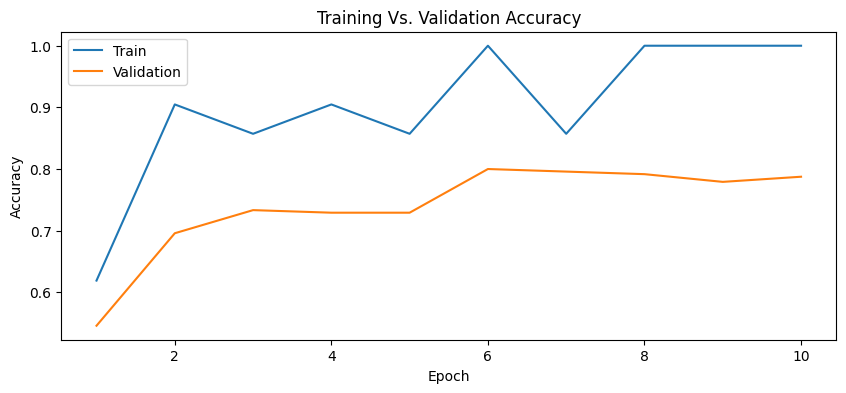

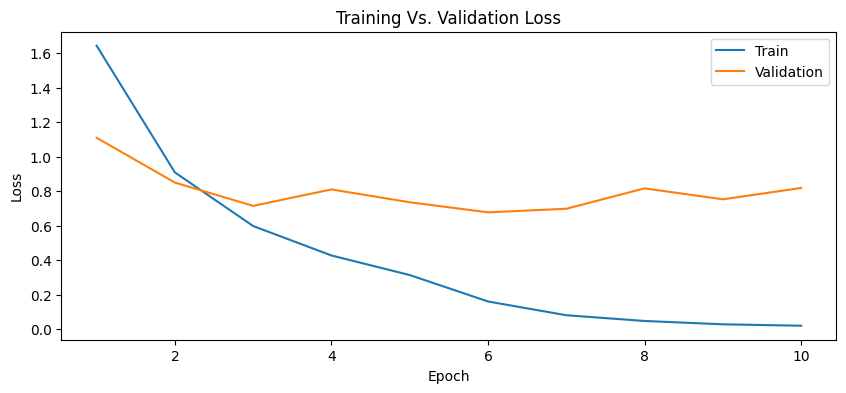

Finished Training
 Final Training Accuracy: 100.0 %
 Final Validation Accuracy: 78.75 %




TrainingResult(Training_accuracy=1.0,
training_loss=0.01999544322902917,
Validation_accuracy=0.7875,
Validation_loss=0.8191307410597801)

In [ ]:
model_alexnet = AlexNetModel().to(device)

train_features_alexnet = torch.load('AlexNet_files/train_features.pt')
train_labels_alexnet = torch.load('AlexNet_files/train_labels.pt')

val_features_alexnet = torch.load('AlexNet_files/val_features.pt')
val_labels_alexnet = torch.load('AlexNet_files/val_labels.pt')

# Create a TensorDataset
train_dataset = TensorDataset(train_features_alexnet, train_labels_alexnet)
train_loader_alexnet = DataLoader(train_dataset, batch_size= 32, shuffle=True)

val_dataset = TensorDataset(val_features_alexnet, val_labels_alexnet)
val_loader_alexnet = DataLoader(val_dataset, batch_size= 32, shuffle=True)

train(model_alexnet, train_loader_alexnet, val_loader_alexnet, batch_size=32, learning_rate=0.01, num_epochs=10)


### Part (iv) - [2pt RESULTS]
Report the test accuracy of your best model. How does the test accuracy compare to Part 3(iv) without transfer learning?

In [ ]:
# TO BE COMPLETED
test_model_alexnet = AlexNetModel().to(device)

model_path = generate_model_path(test_model_alexnet.name, batch_size=32, learning_rate=0.01, num_epochs=10)
state = torch.load(model_path)
print(test_model_alexnet.load_state_dict(state))


<All keys matched successfully>


In [ ]:
criterion = nn.CrossEntropyLoss()

test_features_alexnet = torch.load('AlexNet_files/test_features.pt')
test_labels_alexnet = torch.load('AlexNet_files/test_labels.pt')

test_dataset = TensorDataset(test_features_alexnet, test_labels_alexnet)
test_loader_alexnet = DataLoader(test_dataset, batch_size= 32, shuffle=True)

loss_eval, acc_eval = get_accuracy(test_model_alexnet, criterion, test_loader_alexnet)

print(f"The test classification accuracy is: {acc_eval * 100} %")
print(f"The test loss is: {loss_eval}")


The test classification accuracy is: 78.0 %
The test loss is: 0.9420755878090858


In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

The test accuracy for part 3 without transfer learning was 76.8%. Using transfer learning, we can see that the test accuracy increased a little bit.
The test accuracy with AlexNet turned out to be 78% which shows the effectivness of transfer learning.

'''

## Part 5. Testing on New Data [14pt]
As a final step in testing we will be revisiting the sample images that you had collected and submitted with your assignment. These sample images should be untouched and will be used to demonstrate how well your model works at identifying your hand guestures.



### Part (i) - [2pt EXPLORATORY]
Load and process the hand gesture images you had collected so that they can easily be evaulated by your model.

In [ ]:
data_transform = transforms.Compose([transforms.RandomResizedCrop(224),
                                        transforms.ToTensor()])

data_dir = '/content/personal_dataset'

personal_testdata = ImageFolder(data_dir, transform=data_transform)

personal_testdata_loader = DataLoader(personal_testdata, batch_size= 32)


### Part (ii) - [5pt RESULTS]
Using the best transfer learning model developed in Part 4. Report the test accuracy on your sample images and how it compares to the test accuracy obtained in Part 4(iv)? Also, use your best model from Part 3 to report the test accuracy on the new sample images and how it compares to the test accuracy obtained in Part 3(iv). You should present your results in a pandas DataFrame.

This question will also be evaluated on the overal performance achieved.

In [ ]:
for imgs, labels in personal_testdata_loader:
    personal_test_features = alexnet.features(imgs)
    personal_test_labels = labels

personal_test_dataset = TensorDataset(personal_test_features, personal_test_labels)
personal_test_loader = DataLoader(personal_test_dataset, batch_size=32, shuffle=True)

personal_loss_alexnet, personal_acc_alexnet = get_accuracy(test_model_alexnet, criterion, personal_test_loader)

print(f'The test classification accuracy for AlexNet is: {personal_acc_alexnet * 100} %\n',
      f'The test loss for AlexNet is: {personal_loss_alexnet}')



The test classification accuracy for AlexNet is: 14.814814814814813 %
 The test loss for AlexNet is: 8.049567222595215


In [ ]:
def get_personal_dataloaders(batch_size: int, **kwargs):

    # Transforming the images to Tensors, resizing and normalizing
    mean = [0.485, 0.456, 0.406] #Commonly used values for RGB channels
    std = [0.229, 0.224, 0.225] #Commonly used values for RGB channels

    data_transform = transforms.Compose([transforms.RandomResizedCrop(224), transforms.ToTensor(),
                                         transforms.Normalize(mean, std)])

    # Loading the dataset
    data_dir = '/content/personal_dataset'

    test_data = ImageFolder(data_dir, transform=data_transform)

    # prepare data loaders

    test_load = DataLoader(test_data, batch_size=batch_size,
                                          num_workers=1, shuffle=True)

    return test_load, test_data


In [ ]:
best_model = ASL(kernel_size=5).to(device)
best_hyper_params = dict(batch_size=32, num_epochs=30, learning_rate=0.01)

personal_test_loader_asl, testdata= get_personal_dataloaders(** best_hyper_params)

personal_loss_asl, personal_acc_asl = get_accuracy(best_model, criterion, personal_test_loader_asl)

print(f"The Test classification accuracy for ASL model: {personal_acc_asl * 100} %\nTest Loss for ASL model: {personal_loss_asl}")

The Test classification accuracy for ASL model: 85.18518518518519 %
Test Loss for ASL model: 2.125199556350708


### Part (iii) - [7pt DISCUSSION]
How well did your models do for the different hand guestures? Provide an explanation for why you think your models performed the way it did? Be sure to compare the results of training, validation, testing, and also on the new data represented by your own hand gestures.

How well would this model perform if you were to deploy it in the real-world? List some things you could do to improve the model performance.

In [ ]:
classes = torch.tensor(testdata.targets)

for i in range(9):
    target_index = (classes == i).nonzero()

    sampler = torch.utils.data.sampler.SubsetRandomSampler(target_index)
    personal_test_loader = DataLoader(testdata, batch_size=1024, sampler=sampler)

    for imgs, labels in personal_test_loader:
        personal_test_features = alexnet.features(imgs)
        personal_test_labels = labels

    personal_test_dataset = TensorDataset(personal_test_features, personal_test_labels)
    personal_test_loader = DataLoader(personal_test_dataset, batch_size=32, shuffle=True )


    loss_fi, acc_fi = get_accuracy(test_model_alexnet, criterion, personal_test_loader)
    print(f"Classification accuracy for ASL character  {chr(65+i)} is: {acc_fi * 100}%")
    print(f"Test loss for the same is: {loss_fi}".format(i, loss_fi))



Classification accuracy for ASL character  A is: 18.51851851851852%
Test loss for the same is: 16.753341674804688
Classification accuracy for ASL character  B is: 18.51851851851852%
Test loss for the same is: 16.753339767456055
Classification accuracy for ASL character  C is: 18.51851851851852%
Test loss for the same is: 16.753341674804688
Classification accuracy for ASL character  D is: 18.51851851851852%
Test loss for the same is: 16.753339767456055
Classification accuracy for ASL character  E is: 18.51851851851852%
Test loss for the same is: 16.753339767456055
Classification accuracy for ASL character  F is: 18.51851851851852%
Test loss for the same is: 16.753341674804688
Classification accuracy for ASL character  G is: 18.51851851851852%
Test loss for the same is: 16.753341674804688
Classification accuracy for ASL character  H is: 18.51851851851852%
Test loss for the same is: 16.753339767456055
Classification accuracy for ASL character  I is: 18.51851851851852%
Test loss for the sa

In [ ]:
'''
PROVIDE YOUR ANSWER BELOW

The AlexNet model performed very poorly on my personal dataset. It should have performed very good as it is a small dataset, the model should have overfit the data and thus,
the accuracy should have been 100% but it is not the case. I am not sure where the error is which resulted in such a poor result.

However, the CNN Network architecture without the transfer learning performed very good on both the test dataset of the given dataset as well as on the personal dataset having a
test accuracy of around 86%.

Similarly, I employed finding the individual gesture's accuracy using AlexNet which provided the same results as the personal_dataset outputs showing very poor accuracy for each gesture.
I think the poor performance of the model might be due to the ineffective network architecture as well as the ineffective hyperparameter tuning. Furthermore, the hyperparameters which are
responsible to catch the spatial features might not have been properly used resulting in such poor performance.

Thus, to conclude, the outputs obtained for training, validation and test results for the ASL CNN model without Transfer Learning performed good for the small dataset of personal hands.
However, when using the large dataset, the accuracy of test, validation and training was much better for the AlexNet transfer learning model.

The model if deployed in real world would not provide the best performance for small datasets at the moment due to the issues with AlexNet transfer learning.

Following things can be employed or imroved in the future:

Data augmentation techniques to artificially increase the size of dataset.
Implement regularization techniques such as dropout or L2 regularization to prevent overfitting.
Implement a feedback loop to continuously update and improve your model based on real-world usage and user feedback.
Experimenting with different hyperparameters, such as learning rate, batch size, and network architecture as it can significantly impact the model's convergence and generalization.


'''

# PART C (Optional) - Bonus Challenge!

This is an optional exercise for those that finish the assignment early and would like to take on some additional challenging task.

For this bonus challenge you are asked to explore different techniques to further improve the model for more realistic scenarios where the hands may be in front of various backgrounds, be taken at different scales, rotations, and positions in the image. To build a superior image classification model you can complete one or all of the following tasks.

Tasks:

1. Test your best models (with or without transfer learning) on hand gestures images with backgrounds that are not clean and smooth. You can take your own hand gesture images, or find ones online to test your model. Comment on the performance of your model.
2. Generated additional data by performing data augmentation to replace the clean, smooth backgrounds with backgrounds with different textures. Do this on all your training, validation, and test data. This task can be done manually (could take a long time) or you can implement code that can automate the task. For Example, one approach you could take to automate this task is to use pretrained image segmentation tools to identify the hands in the images and crop them out and put them onto other backgrounds.
3. Improve on your data augmentation by applying scale, rotation, and translation transformations on different backgrounds.
4. Compare the performance of your best CNN models (with and without transfoer learning) trained with data augmentation to the results in 1. where you did not train on images with data augmentation.
5. Implement one of many region proposal tools to detect hand gestures in image frames and put a bounding box around the region with the highest confidence. You can use pretrained YOLO models, or a region proposal tool from openCV.
6. Create a short video demonstration how you can use your hand gesture recognition model to communicate a message using hand gestures.

Bonus marks will be provided based on the number of steps completed. Summarize below your results and anything intersting you learned from the steps that you completed. Bonus marks cannot be accumulated beyond the maximum assignment grade.

In [ ]:
# TO BE COMPLETED




In [ ]:
'''
PROVIDE YOUR ANSWER BELOW






'''

### Saving to HTML
Detailed instructions for saving to HTML can be found <a href="https://stackoverflow.com/questions/53460051/convert-ipynb-notebook-to-html-in-google-colab/64487858#64487858">here</a>. Provided below are a summary of the instructions:

(1) download your ipynb file by clicking on File->Download.ipynb

(2) reupload your file to the temporary Google Colab storage (you can access the temporary storage from the tab to the left)

(3) run the following:

In [ ]:
%%shell
jupyter nbconvert --to html /content/A2_Hand_Gesture_Recognition.ipynb

(4) the html file will be available for download in the temporary Google Colab storage

(5) review the html file and make sure all the results are visible before submitting your assignment to Quercus

# Assignment Grading Rubric
The grading of the assignment will be based on the following categories:

(0) **5 Pt - DATA** Generating new data to evaluate your model.

(1) **9 Pt - EXPLORATORY QUESTIONS** These are basic questions that in most cases can be answered without requiring a fully working and trained neural network model. For example, data loading, processing and visualization, summary statistics, data exploration, model and training setup, etc.

(2) **9 Pt - MODEL** Student has successfully implemented all the required neural network models and has demonstrated successful training of the model without any errors.

(3) **9 Pt - RESULT** Students are evaluated based on the results achieved in comparison to the expected results of the assignment.

(4) **9 Pt - DISCUSSION QUESTIONS** Student demonstrated understanding beyond the basic exploratory questions, can answer some of the more challenging questions, and provide arguments for their model selection decisions.

(5) **9 Pt - COMMUNICATION** Student has provided a quality submission that is easy to read without too many unnecessary output statements that distract the reading of the document. The code has been well commented and all the answers are communicated clearly and concisely.

(6) **10 Pt - BONUS** Student has completed the assignment and has taken on the challenging bonus tasks listed in PART C. The student has demonstrated a good understanding of all aspects of the assignment and has exceeded expectations for the assignment.



**TOTAL GRADE = _____ of 50 Pts**